<a href="https://colab.research.google.com/github/venkateshkumarsingaravelu/machine_learning_workshop/blob/main/yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.1 MB/s eta 0:00:00


In [6]:
# ---------------------------------------------------------
# 1. Install YOLO (Ultralytics)
# ---------------------------------------------------------
!pip install ultralytics

# ---------------------------------------------------------
# 2. Import YOLO
# ---------------------------------------------------------
from ultralytics import YOLO
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 3. Load a pretrained YOLO model
# ---------------------------------------------------------
model = YOLO("yolov8n.pt")   # nano model (fastest)

# ---------------------------------------------------------
# 4. Upload an image
# ---------------------------------------------------------
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ---------------------------------------------------------
# 5. Run YOLO prediction
# ---------------------------------------------------------
results = model.predict(img_path, save=True)
print(results)
# ---------------------------------------------------------
# 6. Display the result
# ---------------------------------------------------------
output_img_path = results[0].save_dir + "/" + results[0].path.split("/")[-1]

img = cv2.imread(output_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.show()


Saving test_image.jpeg to test_image.jpeg

image 1/1 /content/test_image.jpeg: 352x640 2 persons, 2 dogs, 155.2ms
Speed: 3.9ms preprocess, 155.2ms inference, 5.2ms postprocess per image at shape (1, 3, 352, 640)
Results saved to /content/runs/detect/predict-2


error: OpenCV(5.0.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


Saving test_image.jpeg to test_image (1).jpeg

image 1/1 /content/test_image (1).jpeg: 352x640 2 persons, 2 dogs, 133.3ms
Speed: 3.2ms preprocess, 133.3ms inference, 1.2ms postprocess per image at shape (1, 3, 352, 640)


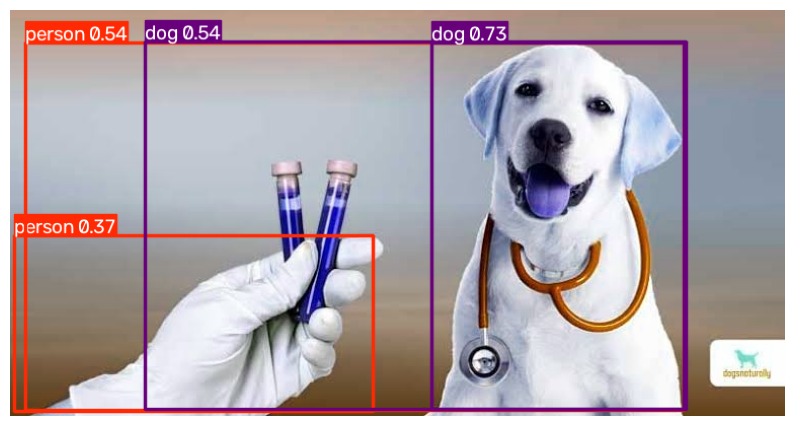

In [7]:
!pip install ultralytics

from ultralytics import YOLO
from google.colab import files
import matplotlib.pyplot as plt

# Load YOLO model
model = YOLO("yolov8n.pt")

# Upload image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Predict
results = model.predict(img_path)

# Display result safely
result_img = results[0].plot()

plt.figure(figsize=(10,10))
plt.imshow(result_img)
plt.axis("off")
plt.show()


In [2]:
import torch
import torch.nn as nn

class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNet, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),

            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),

            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x
